In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv('/content/diabetes_prediction_dataset.csv.zip')

In [4]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df.shape

(100000, 9)

In [6]:
df.columns.to_list()

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'smoking_history',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

In [7]:
df.duplicated().sum()

np.int64(3854)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
print(df.duplicated().sum().sum())

0


In [10]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [12]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [13]:
df['gender'].value_counts()

,count
gender,
Female,56161
Male,39967
Other,18


In [14]:
df['gender'].nunique()

3

In [15]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [16]:
df['smoking_history'].value_counts()

,count
smoking_history,
never,34398
No Info,32887
former,9299
current,9197
not current,6367
ever,3998


In [17]:
df['smoking_history'].nunique()

6

In [18]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [19]:
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], dtype='int64', drop_first=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          96146 non-null  float64
 1   hypertension                 96146 non-null  int64  
 2   heart_disease                96146 non-null  int64  
 3   bmi                          96146 non-null  float64
 4   HbA1c_level                  96146 non-null  float64
 5   blood_glucose_level          96146 non-null  int64  
 6   diabetes                     96146 non-null  int64  
 7   gender_Male                  96146 non-null  int64  
 8   gender_Other                 96146 non-null  int64  
 9   smoking_history_current      96146 non-null  int64  
 10  smoking_history_ever         96146 non-null  int64  
 11  smoking_history_former       96146 non-null  int64  
 12  smoking_history_never        96146 non-null  int64  
 13  smoking_history_not c

In [21]:
df['diabetes'].value_counts()

,count
diabetes,
0,87664
1,8482


In [22]:
print(df['diabetes'].describe(),
      df['diabetes'].skew())

count    96146.000000
mean         0.088220
std          0.283616
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: diabetes, dtype: float64 2.9038452407823976


In [23]:
correlation = df.corr(numeric_only=True)['diabetes'].sort_values(ascending=False)
print(correlation)

diabetes                       1.000000
blood_glucose_level            0.424336
HbA1c_level                    0.406408
age                            0.264927
bmi                            0.214932
hypertension                   0.195710
heart_disease                  0.170711
smoking_history_former         0.095492
gender_Male                    0.037883
smoking_history_never          0.023136
smoking_history_ever           0.021915
smoking_history_not current    0.018921
smoking_history_current        0.017037
gender_Other                  -0.004256
Name: diabetes, dtype: float64


In [24]:
X = df.drop(columns=['diabetes'], axis=1)
y = df['diabetes']

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [26]:
print(X_train.shape,
      X_test.shape,
      y_train.shape,
      y_test.shape)

(76916, 13) (19230, 13) (76916,) (19230,)


In [27]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [28]:
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [29]:
np.mean(X_train_scaled, axis=0)
np.std(X_train_scaled, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [30]:
np.mean(X_test_scaled, axis=0)
np.std(X_test_scaled, axis=0)

array([0.99891271, 0.98797571, 0.99570123, 1.00774487, 1.0037439 ,
       1.00151346, 0.99741306, 1.06900328, 1.002588  , 1.02337058,
       0.98890188, 1.00036625, 0.99340087])

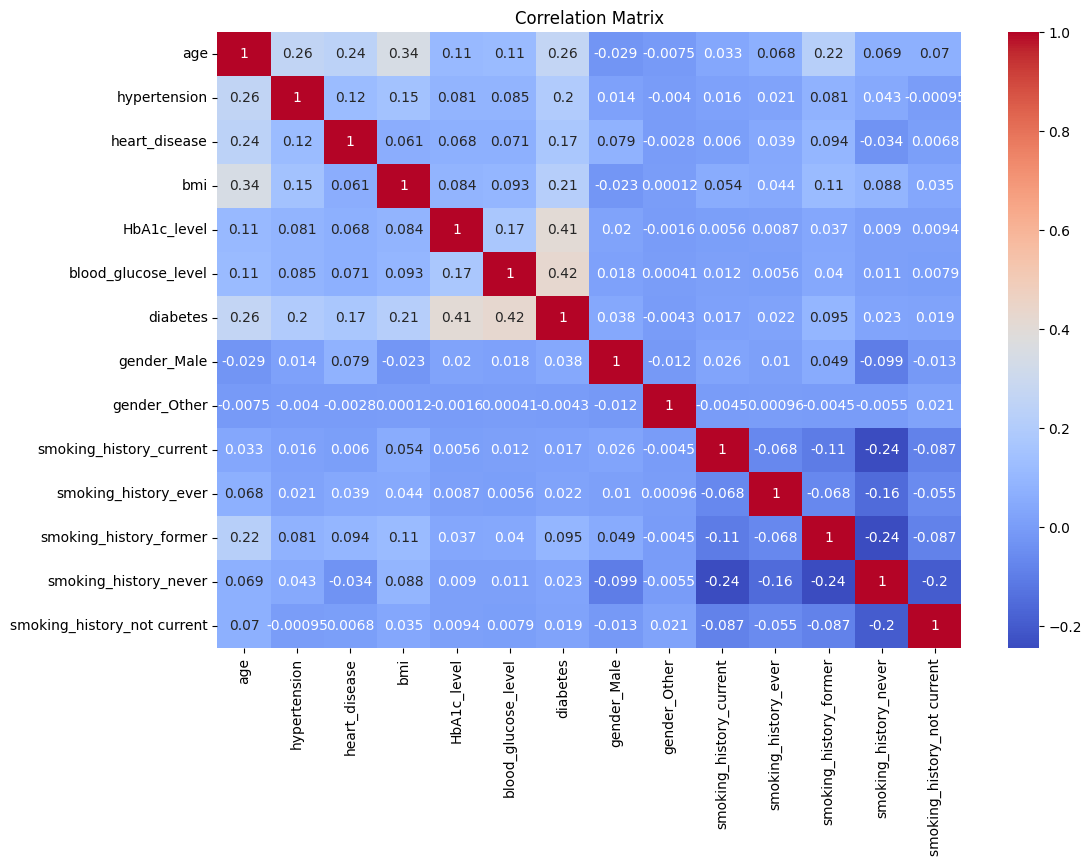

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

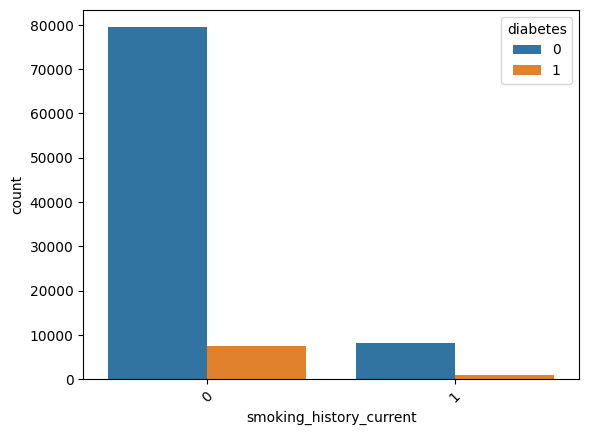

In [32]:
sns.countplot(
    data=df,
    x='smoking_history_current',
    hue='diabetes'
)

plt.xticks(rotation=45)
plt.show()

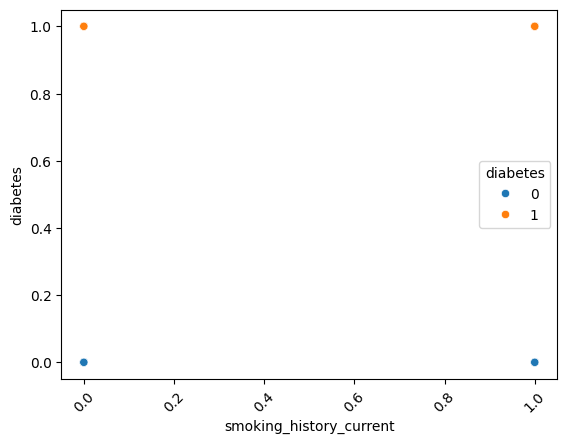

In [33]:
sns.scatterplot(
    data=df,
    x='smoking_history_current',
    y='diabetes',
    hue='diabetes'
)

plt.xticks(rotation=45)
plt.show()

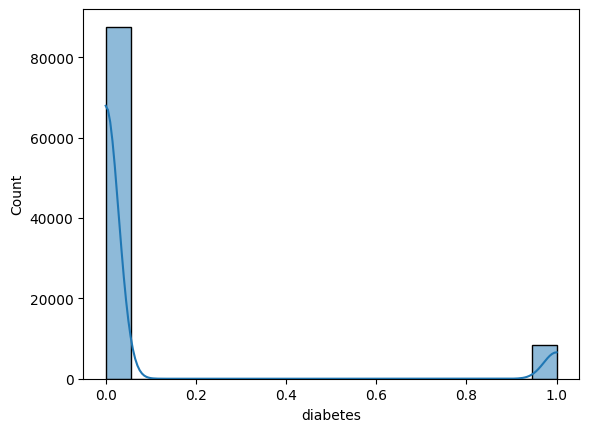

In [34]:
sns.histplot(
    data=df,
    x='diabetes',
    kde=True
)

plt.show()

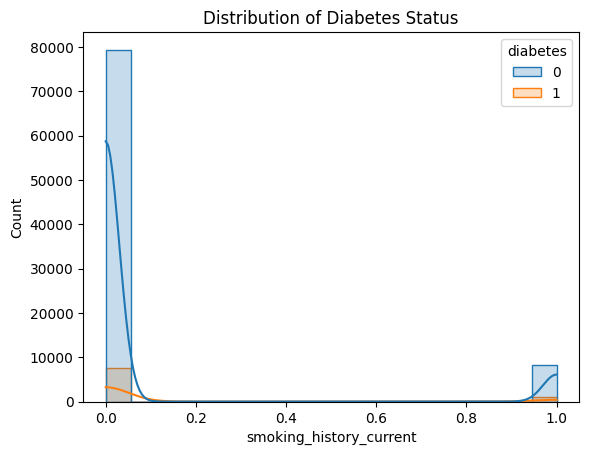

In [35]:
sns.histplot(
    data=df,
    x='smoking_history_current',
    hue='diabetes',
    kde=True,
    element='step'
)
plt.title('Distribution of Diabetes Status')
plt.show()

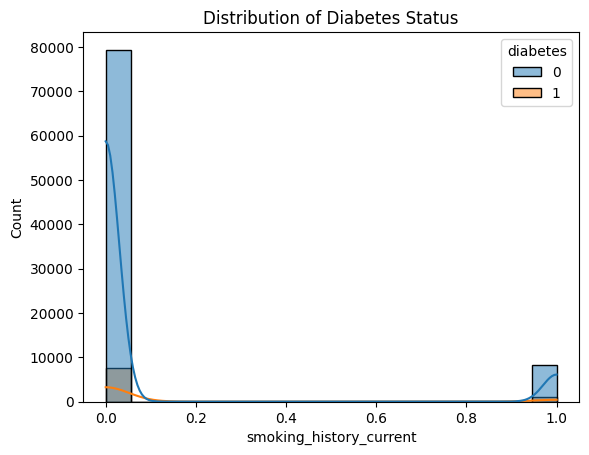

In [36]:
sns.histplot(
    data=df,
    x='smoking_history_current',
    hue='diabetes',
    kde=True
)

plt.title('Distribution of Diabetes Status')
plt.show()

<Axes: ylabel='diabetes'>

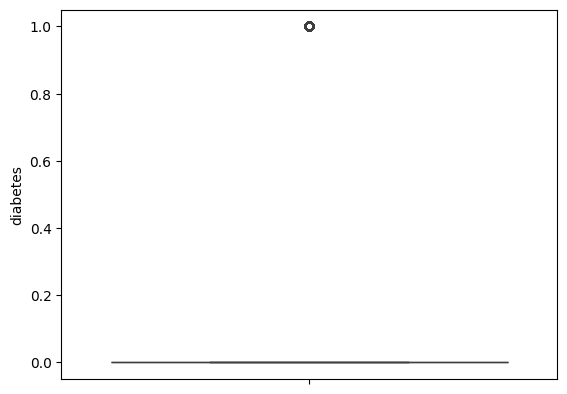

In [37]:
sns.boxplot(df['diabetes'])

In [38]:
q3 = df['diabetes'].describe()['75%']
q1 = df['diabetes'].describe()['25%']
print(q3,q1)

0.0 0.0


In [39]:
IQR = q3-q1
print(IQR)

0.0


In [40]:
upper_limit = q3+1.5*IQR
lower_limit = q1-1.5*IQR
print(upper_limit, lower_limit)

0.0 0.0


In [41]:
df['diabetes'] = df['diabetes'].clip(lower_limit, upper_limit)

<Axes: ylabel='diabetes'>

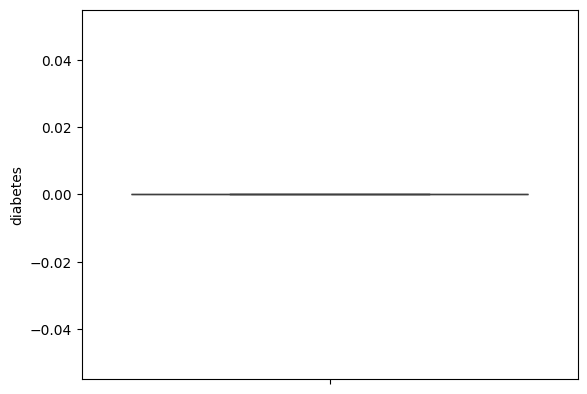

In [42]:
sns.boxplot(df['diabetes'])

In [43]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

In [44]:
model_log.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [45]:
pred_log = model_log.predict(X_test_scaled)

In [46]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(confusion_matrix(y_test, pred_log))
print(classification_report(y_test, pred_log))

print("ROC-AUC:", roc_auc_score(y_test, pred_log))
print("PR-AUC:", average_precision_score(y_test, pred_log))

[[15517  2017]
 [  204  1492]]
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17534
           1       0.43      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230

ROC-AUC: 0.8823416661106939
PR-AUC: 0.3846573658727548


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [48]:
model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('log', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])


In [49]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(
    model_log,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(score)
print("Mean Accuracy:", score.mean())

[0.88985959 0.88600551 0.88834573 0.88423735 0.88345728]
Mean Accuracy: 0.8863810925207304


In [50]:
from sklearn.metrics import classification_report, confusion_matrix

pred_log = model_log.fit(X_train, y_train).predict(X_test)

print(confusion_matrix(y_test, pred_log))
print(classification_report(y_test, pred_log))

[[15517  2017]
 [  204  1492]]
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17534
           1       0.43      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230



In [51]:
from sklearn.metrics import roc_auc_score

pred_proba = model_log.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))

ROC-AUC: 0.9600742344792114


In [52]:
# F1 Score
scores = cross_val_score(model_log, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_log, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_log, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.5778112061981715
Mean Recall: 0.8811595240213027
Mean Balanced Accuracy: 0.8840228887612778


In [53]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [54]:
model_rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [55]:
pred_rf = model_rf.predict(X_test)
pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

In [56]:
print(confusion_matrix(y_test, pred_rf))
print(classification_report(
    y_test,
    pred_rf,
    zero_division=0
))

[[15743  1791]
 [  167  1529]]
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17534
           1       0.46      0.90      0.61      1696

    accuracy                           0.90     19230
   macro avg       0.73      0.90      0.78     19230
weighted avg       0.94      0.90      0.91     19230



In [57]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_rf))

ROC-AUC: 0.9739199420640438


In [58]:
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.63132335 0.62427048 0.63588667 0.61893301 0.62152848]
Mean F1: 0.626388399115666


In [59]:
# F1 Score
scores = cross_val_score(model_rf, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_rf, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_rf, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.626388399115666
Mean Recall: 0.9080397844142272
Mean Balanced Accuracy: 0.9060469432727363


In [60]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [61]:
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [62]:
pred_xgb = model_xgb.predict(X_test)
pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

In [63]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_xgb))
print(classification_report(
    y_test,
    pred_xgb,
    zero_division=0
))

print("ROC-AUC:", roc_auc_score(y_test, pred_proba_xgb))

[[17515    19]
 [  523  1173]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.98      0.69      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.85      0.90     19230
weighted avg       0.97      0.97      0.97     19230

ROC-AUC: 0.9775939529076662


In [64]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_xgb))

ROC-AUC: 0.9775939529076662


In [65]:
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.8086141  0.81271596 0.79112364 0.8161435  0.8066413 ]
Mean F1: 0.8070476999222052


In [66]:
# F1 Score
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.8070476999222052
Mean Recall: 0.6852154467928976
Mean Balanced Accuracy: 0.8419917329950364


In [67]:
from sklearn.ensemble import GradientBoostingClassifier

model_gbr = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [68]:
model_gbr.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [69]:
pred_gbr = model_gbr.predict(X_test)
pred_proba_gbr = model_gbr.predict_proba(X_test)[:, 1]

In [70]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_gbr))
print(classification_report(
    y_test,
    pred_gbr,
    zero_division=0
))

print("ROC-AUC:", roc_auc_score(y_test, pred_proba_gbr))

[[17522    12]
 [  525  1171]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.99      0.69      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230

ROC-AUC: 0.9769439522889222


In [71]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_gbr))

ROC-AUC: 0.9769439522889222


In [72]:
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.80656425 0.81045296 0.78680383 0.81537929 0.80515859]
Mean F1: 0.8048717833857406


In [73]:
# F1 Score
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.8048717833857406
Mean Recall: 0.6789668365928776
Mean Balanced Accuracy: 0.839095572692974


In [77]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print(scores)
print("Mean Balanced Accuracy:", scores.mean())

[0.90672615 0.90121978 0.90984793 0.90346459 0.9028735 ]
Mean Balanced Accuracy: 0.9048263904882121


In [78]:
import joblib

joblib.dump(model_rf, 'diabetes_prediction_model.pkl', compress=3)

print("Model saved successfully!")

Model saved successfully!


In [79]:
loaded_model = joblib.load('diabetes_prediction_model.pkl')

In [80]:
import joblib

joblib.dump(model_rf, "titanic_xgboost_model.pkl")
joblib.dump(scale, "scaler.pkl")

['scaler.pkl']

In [81]:
import joblib

model = joblib.load("titanic_xgboost_model.pkl")
scale = joblib.load("scaler.pkl")

In [83]:
X.columns.tolist()

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'gender_Male',
 'gender_Other',
 'smoking_history_current',
 'smoking_history_ever',
 'smoking_history_former',
 'smoking_history_never',
 'smoking_history_not current']